Разведочный анализ событий: что есть в данных и какие закономерности отличают ботов от людей. 
Выводы отсюда легли в очистку событий и признаки в `src/feature_generation.py`.

## Ключевые выводы

1. Все `captcha_shown` находятся после окна. Признаки считаем строго по событиям внутри окна, иначе модель выучит утечку.

2. Полные дубли случайны, удаляем их. Разные события в одну и ту же секунду — настоящие, оставляем.

3. `platform` в пределах одной куки пишется в разном регистре (`web`/`WEB`/`desktop`). Приводим к трём значениям: `desktop`, `android`, `ios`

4. Пропуски в основном заданы структурой данных: типом события и платформой. Исключение - курсор на desktop: у ботов он пропадает вдвое чаще

5. Чем дальше страница выдачи, тем выше доля ботов

6. Около 78% кук с Python-клиентами в UA размечены как люди. Длина UA - лишь закодированное семейство браузера.

## Данные

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.feature_generation import generate_features
from src.ua_parser import parse_ua

train = pd.read_csv(
    "data/train.csv",
    parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"],
)
test = pd.read_csv(
    "data/test.csv",
    parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"],
)
events = pd.read_csv("data/events.csv.gz", parse_dates=["event_ts"])
pd.set_option("display.width", 1000)

print(train.shape, test.shape, events.shape)
print("доля ботов в train:", train.target.mean().round(4))
train.head()

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [2]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [3]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 328905 entries, 0 to 328904
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   cookie_id      328905 non-null  str           
 1   event_ts       328905 non-null  datetime64[us]
 2   eid            328905 non-null  int64         
 3   event_name     328905 non-null  str           
 4   platform       328905 non-null  str           
 5   user_agent     328905 non-null  str           
 6   item_id        214308 non-null  float64       
 7   item_category  295985 non-null  str           
 8   item_location  305112 non-null  str           
 9   seller_type    195052 non-null  str           
 10  search_query   100402 non-null  str           
 11  search_page    100402 non-null  float64       
 12  pointer_x      108540 non-null  float64       
 13  pointer_y      108540 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(8)
memory usage

Каждое окно наблюдения длится ровно сутки:

In [4]:
(train["window_end_ts"] - train["window_start_ts"]).describe()

count              11091
mean     1 days 00:00:00
std      0 days 00:00:00
min      1 days 00:00:00
25%      1 days 00:00:00
50%      1 days 00:00:00
75%      1 days 00:00:00
max      1 days 00:00:00
dtype: object

In [5]:
col_list = [
    "event_name",
    "platform",
    "user_agent",
    "item_category",
    "item_location",
    "seller_type",
    "search_query",
    "search_page",
]
for col in col_list:
    print(events[col].value_counts() / len(events))
    print("Уникальных значений:", events[col].nunique(), "\n")

event_name
item_view               0.367331
search_results_view     0.305261
photo_swipe             0.111026
favorite_add            0.057916
seller_page_view        0.052912
contact_phone_show      0.034405
captcha_shown           0.024104
login                   0.019054
contact_chat_open       0.018622
contact_message_sent    0.009367
Name: count, dtype: float64
Уникальных значений: 10 

platform
desktop    0.142491
WEB        0.141305
Web        0.140968
web        0.139709
ANDROID    0.129101
Android    0.128469
android    0.128180
iphone     0.012475
IOS        0.012466
iOS        0.012438
ios        0.012399
Name: count, dtype: float64
Уникальных значений: 11 

user_agent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.11.0.0 Safari/537.36    0.011362
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:119.0) Gecko/20100101 Firefox/119.0                                                       0.011158
Mozilla/5.0 (Windows NT

## Пропуски

Дальше работаем только с событиями кук из train: присоединяем к ним окно наблюдения и таргет. <br>
Исходные события сохраняются в `events_raw`.

In [6]:
events_raw = events
events = events.merge(train[["cookie_id", "window_start_ts", "window_end_ts", "target"]], on="cookie_id")

In [7]:
print("пропуски по колонкам:")
print(events.isna().mean().round(3))

пропуски по колонкам:
cookie_id          0.000
event_ts           0.000
eid                0.000
event_name         0.000
platform           0.000
user_agent         0.000
item_id            0.354
item_category      0.109
item_location      0.081
seller_type        0.413
search_query       0.698
search_page        0.698
pointer_x          0.669
pointer_y          0.669
window_start_ts    0.000
window_end_ts      0.000
target             0.000
dtype: float64


Проверим, как пропуски связаны с типом события, платформой и таргетом:

In [8]:
cols = [
    "item_id",
    "item_category",
    "item_location",
    "seller_type",
    "search_query",
    "search_page",
    "pointer_x",
]
na = events[cols].isna()

print(na.groupby(events.event_name).mean().mul(100).round(1), "\n")
print(na.groupby(events.platform).mean().mul(100).round(1), "\n")
print(na.groupby(events.target).mean().mul(100).round(1), "\n")

                      item_id  item_category  item_location  seller_type  search_query  search_page  pointer_x
event_name                                                                                                    
captcha_shown           100.0          100.0          100.0        100.0         100.0        100.0       72.8
contact_chat_open         0.0            6.0            3.2          8.6         100.0        100.0       69.5
contact_message_sent      0.0            6.3            3.0          9.5         100.0        100.0       67.9
contact_phone_show        0.0            6.0            2.8          9.2         100.0        100.0       68.2
favorite_add              0.0            6.4            2.8          9.3         100.0        100.0       64.8
item_view                 0.0            5.9            3.0          9.1         100.0        100.0       67.0
login                   100.0          100.0          100.0        100.0         100.0        100.0       64.0
p

Большая часть пропусков задана структурой данных:
- у `captcha_shown` и `login` нет ни объявления, ни поиска
- у `search_results_view` нет `item_id` и `seller_type`, у остальных событий нет поискового запроса
- у мобильных платформ курсора нет совсем

In [9]:
na.corr().round(2)

,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x
item_id,1.00,0.21,0.25,0.88,-0.89,-0.89,0.01
item_category,0.21,1.00,0.53,0.19,0.10,0.10,0.01
item_location,0.25,0.53,1.00,0.22,0.12,0.12,0.01
seller_type,0.88,0.19,0.22,1.00,-0.79,-0.79,0.01
search_query,-0.89,0.10,0.12,-0.79,1.00,1.00,0.00
search_page,-0.89,0.10,0.12,-0.79,1.00,1.00,0.00
pointer_x,0.01,0.01,0.01,0.01,0.00,0.00,1.00


## Доля ботов по значениям

`target_by_value` показывает долю ботов для каждого значения колонки и lift - во сколько раз она выше базовой доли.

In [10]:
def target_by_value(
    df,
    col,
    target="target",
    cookie_col="cookie_id",
    by_cookie=True,
    min_count=30,
    top=20,
):
    """Доля ботов по значениям колонки.
    by_cookie=True - кука учитывается у каждого своего значения один раз,
    иначе считаем по событиям (куки с большим числом событий весят больше).
    """
    d = df[[cookie_col, col, target]].copy()

    if by_cookie:
        d = d.drop_duplicates([cookie_col, col])
        total = df[cookie_col].nunique()
        base = df.drop_duplicates(cookie_col)[target].mean()
    else:
        total = len(df)
        base = df[target].mean()

    res = d.groupby(col, dropna=False, observed=True)[target].agg(n="size", bots="sum", bot_rate="mean")
    res["share"] = res["n"] / total
    res["lift"] = res["bot_rate"] / base
    res = res[res["n"] >= min_count].sort_values("n", ascending=False).head(top)

    unit = "куки" if by_cookie else "события"
    print(
        f"{col} | единица: {unit} | базовая доля ботов: {base:.3f} | "
        f"уникальных значений: {df[col].nunique(dropna=False)}"
    )
    return res.round(3)


print(target_by_value(events, "platform"), "\n")
# Видно, что одной и той же куке могут соответствовать разные написания платформы, так что надо привести их к одному виду
print(target_by_value(events, "event_name", by_cookie=False), "\n")
print(target_by_value(events, "search_query", by_cookie=False), "\n")

platform | единица: куки | базовая доля ботов: 0.081 | уникальных значений: 11
             n  bots  bot_rate  share   lift
platform                                    
Web       5474   582     0.106  0.494  1.312
desktop   5457   584     0.107  0.492  1.320
WEB       5454   583     0.107  0.492  1.319
web       5411   582     0.108  0.488  1.327
android   4386   282     0.064  0.395  0.793
ANDROID   4365   283     0.065  0.394  0.800
Android   4353   283     0.065  0.392  0.802
iOS        545    26     0.048  0.049  0.589
iphone     531    26     0.049  0.048  0.604
IOS        530    26     0.049  0.048  0.605
ios        517    26     0.050  0.047  0.620 

event_name | единица: события | базовая доля ботов: 0.193 | уникальных значений: 10
                          n   bots  bot_rate  share   lift
event_name                                                
item_view             87069  16776     0.193  0.364  1.000
search_results_view   72321  13647     0.189  0.302  0.980
photo_swipe   

Если у куки есть `captcha_shown`, это бот с вероятностью 0.88. Но капчу показывают уже при подозрении на бота, так что это похоже на утечку. Проверим, где события находятся относительно окна наблюдения:

In [11]:
ev_m = events_raw.merge(train[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id")

print("Всего среди всех событий")
print(ev_m["event_name"].value_counts(), "\n")
print("Всего среди событий внутри окна")
ev = ev_m[(ev_m.event_ts >= ev_m.window_start_ts) & (ev_m.event_ts < ev_m.window_end_ts)]
print(ev["event_name"].value_counts())

Всего среди всех событий
event_name
item_view               87069
search_results_view     72321
photo_swipe             26384
favorite_add            13790
seller_page_view        12549
contact_phone_show       8074
captcha_shown            7928
login                    4506
contact_chat_open        4357
contact_message_sent     2237
Name: count, dtype: int64 

Всего среди событий внутри окна
event_name
item_view               74338
search_results_view     61717
photo_swipe             22951
favorite_add            12037
seller_page_view        10688
contact_phone_show       7046
login                    3900
contact_chat_open        3780
contact_message_sent     1979
Name: count, dtype: int64


In [12]:
# Положение событий относительно окна наблюдения: train и test
meta = pd.concat([train.assign(part="train"), test.assign(part="test")])
ev_pos = events_raw.merge(meta[["cookie_id", "window_start_ts", "window_end_ts", "part"]], on="cookie_id")
ev_pos["position"] = np.select(
    [ev_pos.event_ts < ev_pos.window_start_ts, ev_pos.event_ts >= ev_pos.window_end_ts],
    ["до окна", "после окна"],
    default="в окне",
)
display(pd.crosstab(ev_pos.part, ev_pos.position))

# Доля событий ботов в train внутри окна и после него
ev_pos_train = ev_pos[ev_pos.part == "train"].merge(train[["cookie_id", "target"]], on="cookie_id")
ev_pos_train.groupby("position").target.mean().round(3)

position,в окне,после окна
part,,
test,89690,0
train,198436,40779


position
в окне        0.134
после окна    0.480
Name: target, dtype: float64

Утечка подтверждается:
- события после окна есть только в train, в test их нет; среди них доля событий ботов 0.48 против 0.134 внутри окна;
- все `captcha_shown` находятся после окна. Это реакция антибота уже после наблюдения

Поэтому оставляем только события внутри окна. 

Заодно приводим `platform` к трём значениям: одна и та же кука пишется то `web`, то `WEB`, то `desktop`.

In [13]:
events["platform"] = events["platform"].str.lower().replace({"web": "desktop", "iphone": "ios"})
events = events[(events.event_ts >= events.window_start_ts) & (events.event_ts < events.window_end_ts)]

In [14]:
# После фильтра по окну и нормализации платформы
print(target_by_value(events, "platform"), "\n")
print(target_by_value(events, "event_name", by_cookie=False), "\n")

platform | единица: куки | базовая доля ботов: 0.081 | уникальных значений: 3
             n  bots  bot_rate  share   lift
platform                                    
desktop   5917   588     0.099  0.533  1.226
android   4595   285     0.062  0.414  0.765
ios        579    26     0.045  0.052  0.554 

event_name | единица: события | базовая доля ботов: 0.134 | уникальных значений: 9
                          n   bots  bot_rate  share   lift
event_name                                                
item_view             74338  11568     0.156  0.375  1.165
search_results_view   61717   9318     0.151  0.311  1.130
photo_swipe           22951   1860     0.081  0.116  0.607
favorite_add          12037    720     0.060  0.061  0.448
seller_page_view      10688   1563     0.146  0.054  1.095
contact_phone_show     7046    685     0.097  0.036  0.728
login                  3900    207     0.053  0.020  0.397
contact_chat_open      3780    376     0.099  0.019  0.745
contact_message_sent  

Доля событий ботов внутри окна 

In [15]:
events["target"].value_counts() / len(events)

target
0    0.86642
1    0.13358
Name: count, dtype: float64

## Дубликаты

In [16]:
full_dups = events[events.duplicated(keep="first")]
print(f"полных дублей: {len(full_dups)} ({len(full_dups) / len(events):.1%} событий)")
print(full_dups["target"].value_counts() / len(full_dups))
# соотношение target в дубликатах почти не отличается от соотношения в целом датасете, что может говорить о том, что полные дубликаты вероятно случайны
events = events.drop_duplicates(keep="first")

полных дублей: 2954 (1.5% событий)
target
0    0.863913
1    0.136087
Name: count, dtype: float64


In [17]:
key = ["cookie_id", "event_ts"]
dups = events[events.duplicated(subset=key, keep=False)].sort_values(key)
dups["target"].value_counts() / len(dups)
# соотношение target в дубликатах по ['cookie_id', 'event_ts'] значительно отличается от соотношения в целом датасете,
# что может говорить о зависимости. Так что их удалять не стоит.

target
0    0.965753
1    0.034247
Name: count, dtype: float64

## Глубина поиска

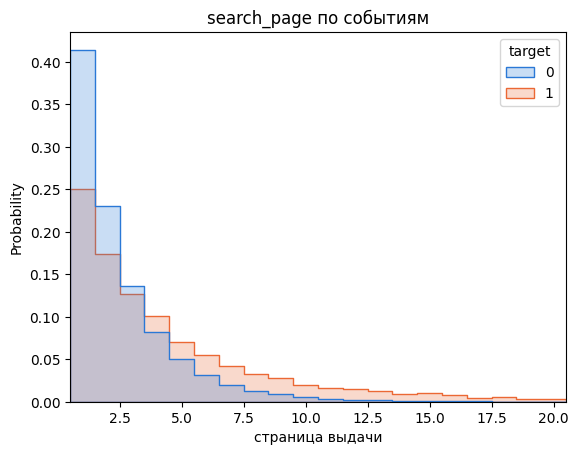

In [18]:
sns.histplot(
    data=events,
    x="search_page",
    hue="target",
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step",
    palette={0: "#2a78d6", 1: "#eb6834"},
)
plt.xlim(0.5, 20.5)  # 99% кук не дальше 20-й страницы, хвост до 63
plt.title("search_page по событиям")
plt.xlabel("страница выдачи")
plt.show()

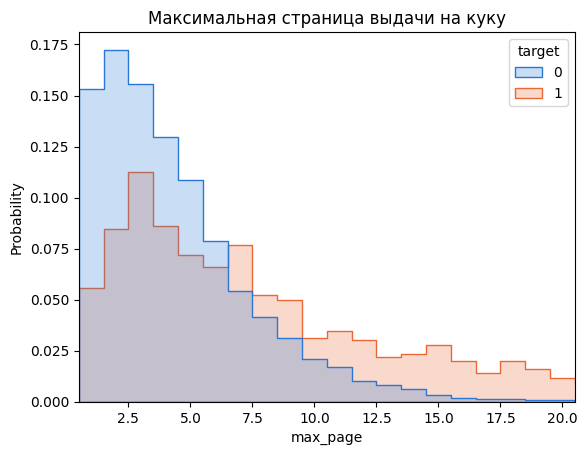

In [19]:
page = events.groupby("cookie_id").agg(max_page=("search_page", "max"), target=("target", "first")).dropna()

sns.histplot(
    data=page,
    x="max_page",
    hue="target",
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step",
    palette={0: "#2a78d6", 1: "#eb6834"},
)
plt.xlim(0.5, 20.5)
plt.title("Максимальная страница выдачи на куку")
plt.xlabel("max_page")
plt.show()

Чем дальше страница выдачи, тем выше доля ботов: они листают выдачу глубже людей. На уровне куки (`max_page`) тенденция та же.

## Курсор на desktop

In [20]:
# Пропуски на desktop по таргету
desktop = events[events["platform"] == "desktop"]
print(desktop[cols].isna().groupby(desktop.target).mean().mul(100).round(1), "\n")

        item_id  item_category  item_location  seller_type  search_query  search_page  pointer_x
target                                                                                          
0          32.8            8.1            5.2         38.8          69.3         69.3       33.8
1          37.9            6.7            3.8         43.5          62.8         62.8       67.0 



Пропуски `pointer_x` на desktop не случайны. У ботов события без курсора встречаются чаще, чем у людей. Отсюда признаки курсора и число его точек в `feature_generation.py`.

## User-Agent

In [21]:
unq_events = events.drop_duplicates("cookie_id")
python_ua = unq_events["user_agent"].str.contains("py", case=False)
print("Кук с Python-клиентами в UA (requests, urllib3, Scrapy):", python_ua.sum(), "\n")
print(unq_events[python_ua]["user_agent"].unique(), "\n")
print(unq_events[python_ua]["target"].value_counts() / len(unq_events[python_ua]))

Кук с Python-клиентами в UA (requests, urllib3, Scrapy): 93 

<StringArray>
['python-urllib3/2.0.7', 'Scrapy/2.11.0 (+https://scrapy.org)', 'python-requests/2.31.0']
Length: 3, dtype: str 

target
0    0.784946
1    0.215054
Name: count, dtype: float64


Около 78% кук с Python-клиентами в UA размечены как люди. Значит, либо ошибка в разметке, либо UA подменили(но зачем?). <br>
Стоит уточнить как собирались данные, что точно понять ошибка в разметке или нет. <br>
Разобранные поля UA используем как обычные признаки.

In [22]:
uniq = events["user_agent"].drop_duplicates()
ua_parsed = pd.DataFrame([parse_ua(u) for u in uniq], index=uniq)
events = events.join(ua_parsed, on="user_agent")

# на уровне куки: основной UA + признаки смены UA
ua_ck = (
    events.groupby("cookie_id")
    .agg(
        ua_main=("user_agent", lambda s: s.mode().iat[0]),
        n_ua=("user_agent", "nunique"),
        n_ua_os=("ua_os", "nunique"),
        n_ua_browser=("ua_browser", "nunique"),
    )
    .join(ua_parsed, on="ua_main")
)

In [23]:
ua_ck.isna().mean().round(3)

ua_main           0.000
n_ua              0.000
n_ua_os           0.000
n_ua_browser      0.000
ua_kind           0.000
ua_os             0.000
ua_os_ver         0.533
ua_browser        0.000
ua_browser_ver    0.018
ua_engine_ver     0.228
ua_device         0.000
dtype: float64

In [24]:
col_list = ua_ck.columns
for col in col_list:
    print(ua_ck[col].value_counts(dropna=False) / len(ua_ck))
    print("Уникальных значений:", ua_ck[col].nunique(), "\n")

ua_main
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 YaBrowser/23.9.0.0 Safari/537.36    0.011361
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36                       0.011270
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:116.0) Gecko/20100101 Firefox/116.0                                                      0.010729
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/118.0.0.0 Safari/537.36                       0.010459
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 YaBrowser/23.0.0.0 Safari/537.36    0.010369
                                                                                                                                        ...   
Scrapy/2.11.0 (+https://scrapy.org)                                                                                                   

Зависимость доли ботов от длины UA:

In [25]:
ck = events.groupby("cookie_id").agg(
    ua_main=("user_agent", lambda s: s.mode().iat[0]), target=("target", "first")
)
ck["ua_len"] = ck.ua_main.str.len()
ck = ck.join(ua_parsed[["ua_kind", "ua_os", "ua_browser"]], on="ua_main")

(
    ck.groupby("ua_len")
    .agg(
        n=("target", "size"),
        bot_rate=("target", "mean"),
        browsers=("ua_browser", lambda s: ", ".join(sorted(set(s)))),
    )
    .round(3)
)

,n,bot_rate,browsers
ua_len,,,
10,32,0.250,curl
16,33,0.273,node-fetch
18,42,0.167,go-http-client
20,31,0.194,python-urllib3
22,27,0.185,python-requests
35,35,0.257,scrapy
42,387,0.044,avito_app
48,1754,0.103,avito_app
80,1399,0.084,firefox


У каждой длины UA есть «своё» семейство браузера или клиента, поэтому `ua_len` - просто закодированное семейство, ОС и модель устройства. В признаки берём разобранные поля UA, а не длину.

## Признаки

Итоговые признаки из `src/feature_generation.py` на train: одна строка на куку.

In [26]:
features = generate_features(events_raw, train)
features.describe().T

,count,mean,std,min,25%,50%,75%,max
n_ua,11091.0,1.133892,0.490134,1.000000,1.000000,1.000000,1.000000,3.000000
n_ua_os,11091.0,1.039131,0.193915,1.000000,1.000000,1.000000,1.000000,2.000000
n_ua_browser,11091.0,1.070417,0.298479,1.000000,1.000000,1.000000,1.000000,3.000000
max_page,10170.0,4.829597,4.105810,1.000000,2.000000,4.000000,6.000000,63.000000
mean_page,10170.0,2.423558,1.252514,1.000000,1.500000,2.125000,3.000000,13.000000
ptr_std_x,3922.0,521.135110,156.258945,7.778175,472.701090,546.066271,603.845954,1247.336362
ptr_std_y,3922.0,294.582382,80.809610,0.707107,263.263899,305.423061,337.798499,696.500179
ptr_mean_x,4046.0,938.460625,235.659589,18.000000,825.314286,955.875000,1066.619048,1892.000000
ptr_mean_y,4046.0,538.577047,130.923066,9.000000,474.910985,540.501466,605.247024,1079.000000
ptr_range_x,4046.0,1412.668809,498.389367,0.000000,1202.250000,1603.000000,1780.000000,1919.000000


Медианы ключевых признаков у людей и ботов — основание для идей признаков из README. Какие признаки на самом деле помогают модели на новых данных, показывает permutation importance в `train.ipynb`.

In [27]:
target = train.set_index("cookie_id")["target"]
key_features = ["ptr_std_x", "ptr_range_x", "n_item_id", "ratio_loc", "ratio_cat",
                "max_page", "mean_page", "n_events", "dt_median", "cookie_age_days"]
features[key_features].join(target).groupby("target").median().T.round(3)

target,0,1
ptr_std_x,552.898,202.539
ptr_range_x,1632.000,719.000
n_item_id,6.000,10.000
ratio_loc,0.416,0.407
ratio_cat,0.176,0.091
max_page,4.000,7.000
mean_page,2.000,3.191
n_events,12.000,20.000
dt_median,60.500,25.000
cookie_age_days,61.782,18.968


- **Курсор:** у ботов он держится в узкой области: медианный разброс по x около 200 против 550 у людей.
- **Объявления и категории:** боты смотрят больше объявлений, но в меньшем числе категорий на событие.
- **Поиск:** боты листают выдачу глубже.
- **Темп:** боты действуют быстрее.
- **Возраст куки:** у ботов куки моложе, около 19 дней против 62.
- **Города:** доля разных городов на событие у ботов и людей почти одинаковая.